# Анализ результатов A/B-тестирования

### О проекте

Исследовательский проект по анализу результатов A/B-тестирования упрощённого интерфейса.

**Цель исследования**: проверить гипотезу, которая заключается в следующем: упрощение интерфейса приведёт к тому, что в течение 7 дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на 3 процентных пункта.

---

### Задачи

- Загрузить и подготовить данные об участниках A/B-теста и действиях пользователей.
- Проверить корректность проведения A/B-теста: состав групп, наличие дубликатов, пересечений пользователей и другие возможные нарушения условий эксперимента.
- Рассчитать конверсию в покупку для контрольной и тестовой групп за первые 7 дней после регистрации.
- Сформулировать статистические гипотезы и выбрать подходящий статистический критерий для их проверки.
- Проверить гипотезу теста о приросте конверсии в группе B как минимум на 3 процентных пункта.
- Оценить статистическую значимость полученных результатов и определить, есть ли основания считать новый интерфейс более эффективным.
- Сформулировать итоговые выводы и рекомендации по результатам A/B-тестирования.

---

### Данные

В исследовании использованы два набора данных:

Данные об пользователях — `ab_test_participants.csv`<br>
Данные о событиях — `ab_test_events.csv`

#### `ab_test_participants.csv`

- `user_id` — идентификатор пользователя;
- `group` — группа пользователя;
- `ab_test` — название теста;
- `device` — устройство, с которого происходила регистрация.

#### `ab_test_events.csv`

- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время события;
- `event_name` — тип события;
- `details` — дополнительные данные о событии.

---

### Этапы работы

1. Загрузка и предобработка данных
2. Проверка корректности проведения A/B-теста
3. Оценка результата тестирования
4. Итоговый вывод

---

## Загрузка и предобработка данных

In [39]:
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [2]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

#### Просмотр таблицы `participant`

In [3]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [4]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [5]:
for i in participants.select_dtypes(include=['object']).columns: 
    print('')
    print(i)
    display(participants[i].unique())


user_id


array(['0002CE61FF2C4011', '001064FEAAB631A1', '0010A1C096941592', ...,
       'FFEFC0E55C1CCD4F', 'FFF28D02B1EACBE1', 'FFF58BC33966EB51'],
      shape=(13638,), dtype=object)


group


array(['B', 'A'], dtype=object)


ab_test


array(['interface_eu_test', 'recommender_system_test'], dtype=object)


device


array(['Mac', 'Android', 'iPhone', 'PC'], dtype=object)

---
#### Просмотр таблицы `events`

In [6]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


In [7]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [8]:
for i in events.select_dtypes(include=['object']).columns: 
    print('')
    print(i)
    display(events[i].unique())


user_id


array(['GLOBAL', 'CCBE9E7E99F94A08', 'AA346F4D22148024', ...,
       'B77B2F4BCA134618', 'B12AD1623E494FAD', '5456977474344433'],
      shape=(144184,), dtype=object)


event_name


array(['End of Black Friday Ads Campaign', 'registration', 'product_page',
       'login', 'product_cart', 'purchase',
       'Start of Christmas&New Year Promo',
       'Start of CIS New Year Gift Lottery'], dtype=object)


details


array(['ZONE_CODE15', '0.0', nan, '-2.0', '-5.0', '-3.5', '-1.5', '-0.5',
       '-2.5', '-4.0', '-4.5', '4.99', '9.99', '-6.0', '-5.5', '-3.0',
       '-1.0', '499.99', '-7.0', '99.99', '-6.5', '4.59',
       '4.890000000000001', '-7.5', '-9.0', '-8.5', '-9.5', '-8.0',
       '9.49', '9.59', '99.89', '99.58999999999999', '4.49', '9.89',
       '-0.48', '-2.38', '-2.85', '-6.18', '-4.27', '-3.8', '-4.75',
       '-3.32', '-5.22', '-5.7', '-7.6', '-8.55', '-9.02', '-1.42',
       '-1.9', '-8.07', '-6.65', '-0.95', '-7.12', '-0.4', '99.49',
       '-0.88', '-4.2', '499.59', '4.09', '99.59', '-2.3', '499.89',
       '4.390000000000001', '4.79', '-0.45', '-3.16', '-2.26', '-4.51',
       '-4.06', '-5.87', '-1.35', '-2.71', '-3.61', '-5.41', '-7.22',
       '-0.9', '-8.12', '-4.96', '-1.8', '-6.32', '-6.77', '-7.67',
       '-8.57', '9.69', '9.79', '99.79', '9.39', '99.69', '499.49',
       '499.39', '-4.46', '3.99', '99.39', '499.79', '99.29', '-1.29',
       '-8.15', '-2.14', '-0.43', '-2

#### Предобработка

In [9]:
# Посмотрим значения event_name, который имеют пропуски в details. Чтобы убедиться в отсутствии пропусков в столбцах, в которых их не должно быть.
events[events['details'].isna()]['event_name'].unique()

array(['product_page', 'login', 'product_cart'], dtype=object)

Проверим дубликаты

In [10]:
participants.duplicated().sum()

np.int64(0)

In [11]:
events.duplicated().sum()

np.int64(36318)

In [12]:
events[events.duplicated()]

,user_id,event_dt,event_name,details
50,A39D63750BBE9B34,2020-12-01 00:08:24,login,NaN
132,631020621D23464A,2020-12-01 00:25:03,login,NaN
278,AD6541E75198ABEF,2020-12-01 00:48:46,login,NaN
390,ADBBC43BED1249C8,2020-12-01 01:06:02,product_cart,NaN
446,928AD890A8E7BDE7,2020-12-01 01:11:10,login,NaN
...,...,...,...,...
787141,GLOBAL,2020-12-31 23:21:18,purchase,4.49
787200,GLOBAL,2020-12-31 23:36:55,purchase,4.49
787209,GLOBAL,2020-12-31 23:39:41,product_cart,NaN
787217,F9C2F1ECC9624248,2020-12-31 23:42:17,product_page,NaN


In [13]:
events[events.user_id == 'GLOBAL'].shape[0]

58495

Избавимся от дубликатов. По умолчанию останутся только первые вхождения в таблицы, а повторные удалятся

In [14]:
events.drop_duplicates(inplace=True)

#### Промежуточный вывод

В таблице `events` присутствует 36318 дубликатов.<br>
Причиной этого может служить, что часть пользователей имеет одинаковый `user_id`, например `GLOBAL` встречается в 36318 строках.<br>
Например это могут быть не авторизованые пользователи, которые совершали действия одновременно. Это не удивательно при таком количестве строк. <br>
Приятно решение удалить дубли оставим их первое вхождение в таблицу.

---

## Проверка корректности проведения A/B теста

In [15]:
participants_interface = participants[participants.ab_test=='interface_eu_test']
print(f'Размер таблицы с пользователями: {participants_interface.shape[0]}')

Размер таблицы с пользователями: 10850


In [16]:
participants_interface['group'].value_counts()

group
B    5467
A    5383
Name: count, dtype: int64

Проверим наличие пересечений между группами

In [17]:
participants_rec_system = participants[participants.ab_test=='recommender_system_test']

intersection_users = set(participants_interface['user_id']) & set(participants_rec_system['user_id'])

print(f'Количество пользователей одновременно в двух группах: {len(intersection_users)}')

Количество пользователей одновременно в двух группах: 887


Исключим пользователей, которые участвуют в конкурирующем тесте.

In [18]:
participants_interface = participants_interface[~participants_interface['user_id'].isin(intersection_users)]

print(f'Размер таблицы после исключения пересечений: {participants_interface.shape[0]}')

Размер таблицы после исключения пересечений: 9963


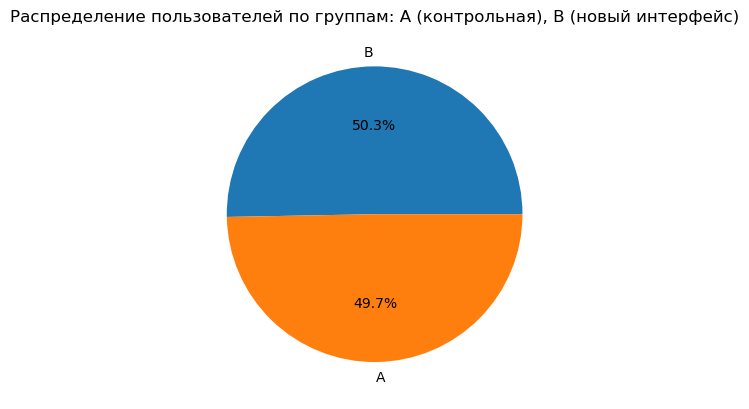

In [19]:
participants_interface['group'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Распределение пользователей по группам: А (контрольная), B (новый интерфейс)')
plt.ylabel('')
plt.show()

Филтруем таблицу `events`, оставляем только данные о пользователях участвующих в нашем тесте.

In [20]:
events_test = events[events['user_id'].isin(set(participants_interface['user_id']))]

#### Определим горизонт анализа: оставим только те события, которые были выполнены в течение первых 7 дней с момента регистрации

Создадим отдельную таблицу с датой регистрации пользователя

In [21]:
user_registration = events_test[events_test.event_name == 'registration'][['user_id', 'event_dt']].rename(columns={'event_dt':'reg_dt'})

Присоединим дату регистрации к основной таблице

In [22]:
events_test = events_test.merge(user_registration, on='user_id', how='left')

Найдем разницу в дням между датой события `event_dt` и датой регистрации `reg_dt`, которые присоединили ранее и фильтруем по количеству дней между событиями `<=7`. Затем удаляем ненужный столбец `reg_dt`

In [23]:
events_test = events_test[(events_test['event_dt'] - events_test['reg_dt']) <= pd.Timedelta(days=7)].drop(columns='reg_dt')

---
#### Считаем необходимый размер выборки для теста

In [24]:
alpha = 0.05  # Уровень значимости
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

In [25]:
group_A_size = participants_interface[participants_interface.group == 'A']['user_id'].nunique()
group_B_size = participants_interface[participants_interface.group == 'B']['user_id'].nunique()

print(f'Размер группы A: {group_A_size}')
print(f'Размер группы B: {group_B_size}')
print(f'Необходимый размер каждой группы: {int(sample_size)}')

Размер группы A: 4952
Размер группы B: 5011
Необходимый размер каждой группы: 3761


Расчёт показал, что для выявления минимального эффекта в 3 п.п. при базовой конверсии 30%, уровне значимости 5% и мощности теста 80% необходимо не менее 3761 пользователя в каждой группе.<br>
Фактический размер групп A и B составляет 4952 и 5011 пользователей соответственно. Обе группы превышают необходимый размер выборки, поэтому выборка достаточна для получения статистически значимых результатов.

---

Объединим таблицу с данными о пользователях `participants_interface` с таблицей с данными о событиях `events_test`

In [33]:
df = participants_interface.merge(events_test, on='user_id', how='inner')

---

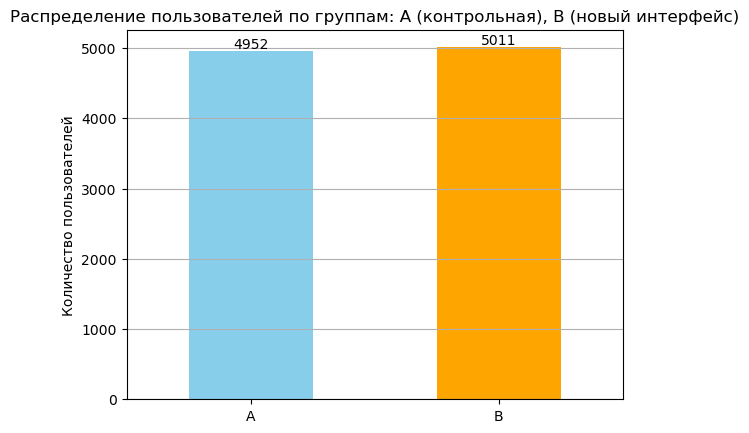

In [27]:
users_by_group = df.groupby('group')['user_id'].nunique()

users_by_group.plot(kind='bar', rot=0, color=['skyblue', 'orange'])

for i, v in enumerate(users_by_group.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.title('Распределение пользователей по группам: А (контрольная), B (новый интерфейс)')
plt.xlabel('')
plt.ylabel('Количество пользователей')
plt.grid(axis='y')

plt.show()

In [28]:
group_A_users_count = df[df.group == 'A']['user_id'].nunique()
group_B_users_count = df[df.group == 'B']['user_id'].nunique()

print(f"Процентная разница в числе уникальных пользователей: {100 * ((group_A_users_count - group_B_users_count) / group_A_users_count):.1f}%")

Процентная разница в числе уникальных пользователей: -1.2%


#### Расчет конверсии пользователей в покупку

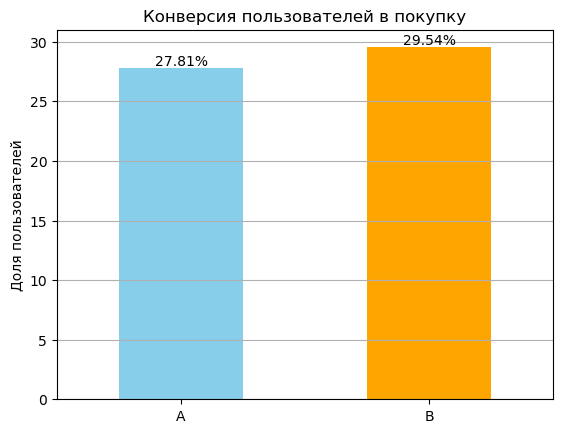

In [29]:
buyers_by_group = df[df.event_name == 'purchase'].groupby('group')['user_id'].nunique()

conversion_by_group = (buyers_by_group / users_by_group)*100

conversion_by_group.plot(kind='bar', rot=0, color=['skyblue', 'orange'])

for i, v in enumerate(conversion_by_group.values):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.title('Конверсия пользователей в покупку')
plt.xlabel('')
plt.ylabel('Доля пользователей')
plt.grid(axis='y')

plt.show()

In [38]:

print(f"Разница в конверсии пользователей в покупателей между группой B и группой A (B - A): {(conversion_by_group['B'] - conversion_by_group['A']):.2f}%")

Разница в конверсии пользователей в покупателей между группой B и группой A (B - A): 1.73%


#### Прожеуточный вывод
Конверсия в покупателей различается на **1.73 процентных пункта**. <br> 
В группе тестовой группе - `B` конверсия пользователей в покупателей больше чем в контрольной группе `A` <br>

Предварительно можем сделать вывод, что **новый упрощенный интерфейс положительно влияет на конверсию пользователей в покупку**. <br>

## Оценка результата A/B-тестирования:

Проверяем гипотезу, которая заключается в следующем: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на 3%.

- Нулевая гипотеза H₀: Упрощение интерфейса не приводит к увеличению конверсии зарегистрированных пользователей в покупателей в течение 7 дней после регистрации. Конверсия в группе `B` не выше, чем в контрольной группе `A`.

- Альтернативная гипотеза H₁: Упрощение интерфейса приводит к увеличению конверсии зарегистрированных пользователей в покупателей в течение 7 дней после регистрации. Конверсия в группе `B` выше, чем в контрольной группе `A`.

In [31]:
group_A_buyers_count = df[(df.group == 'A') & (df.event_name == 'purchase')]['user_id'].nunique()
group_B_buyers_count = df[(df.group == 'B') & (df.event_name == 'purchase')]['user_id'].nunique()

print('Покупателей в группе А:', group_A_buyers_count)
print('Покупателей в группе B:', group_B_buyers_count)

Покупателей в группе А: 1377
Покупателей в группе B: 1480


In [32]:
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [group_A_buyers_count, group_B_buyers_count], 
    [group_A_users_count, group_B_users_count], 
    alternative='smaller'
)
print(f'p-value z-теста: {round(p_value_ztest, 2)}')

p-value z-теста: 0.03


## Итоговый вывод

Для проверки изменения конверсии был выбран односторонний z-тест для сравнения двух независимых выборок с уровнем статистической значимости alpha = 0.05. <br>

По результатам теста p-value = 0.03. Поскольку p-value < alpha, нулевая гипотеза отвергается. Это означает, что есть статистически значимые основания утверждать, что упрощение интерфейса увеличивает конверсию зарегистрированных пользователей в покупателей в течение первых 7 дней после регистрации. <br>

**Фактическая разница конверсий между группами составила 1.73 процентных пункта. Делаем вывод, что статистически значимое увеличение конверсии наблюдается, но ожидаемый эффект в размере не менее 3 процентных пунктов не достигнут.**

**Упрощение интерфейса положительно повлияло на конверсию, но величина полученного эффекта оказалась ниже запланированой.**